# Import Library

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

# Import File

In [22]:
df = pd.read_csv("eye_tracking_dataset_3.csv")

In [7]:
print(df.head())
print(df["label"].value_counts())

   avg_velocity  max_velocity  std_velocity  total_distance  fixation_ratio  \
0      0.361968      1.253364      0.403662        3.979800        0.000000   
1      0.536203      1.626338      0.494673        5.549393        0.000000   
2      0.402936      2.437280      0.557468        4.184695        0.000000   
3      0.395435      1.546485      0.418128        4.101271        0.000000   
4      0.377066      1.664265      0.382938        3.911977        0.033333   

   unique_area_count                                               file  \
0                  5  hasil_tes_0ad2a13e-3b8c-47b4-a072-9efd53746165...   
1                  6  hasil_tes_0ad2a13e-3b8c-47b4-a072-9efd53746165...   
2                  5  hasil_tes_0ad2a13e-3b8c-47b4-a072-9efd53746165...   
3                  5  hasil_tes_0ad2a13e-3b8c-47b4-a072-9efd53746165...   
4                  4  hasil_tes_0ad2a13e-3b8c-47b4-a072-9efd53746165...   

    label  
0  sedang  
1  sedang  
2  sedang  
3  sedang  
4  sedang  
la

# Preprocessing Data

In [8]:
X = df.drop(columns=["file", "label"])
y = df["label"]

le = LabelEncoder()
y = le.fit_transform(y)

print(le.classes_)  # untuk cek mapping label

['normal' 'sedang' 'tinggi']


<Axes: xlabel='label', ylabel='avg_velocity'>

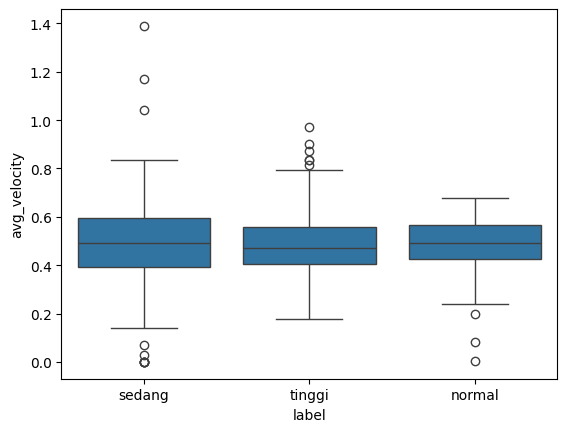

In [9]:
sns.boxplot(data=df, x='label', y='avg_velocity')

# Split Data

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

# Scaler

In [29]:
scaler = StandardScaler()

X_res = scaler.fit_transform(X_res)
X_test = scaler.transform(X_test)

# Searching best parameter for Random Forest

In [30]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_res, y_res)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
0.6688862877252726


# Get Accuracy

In [31]:
best_model = grid.best_estimator_

In [32]:
print(type(best_model))
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Test Accuracy:", acc)
print(classification_report(y_test, y_pred))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
Test Accuracy: 0.5116279069767442
              precision    recall  f1-score   support

           0       0.25      0.36      0.29        14
           1       0.58      0.38      0.46        37
           2       0.60      0.71      0.65        35

    accuracy                           0.51        86
   macro avg       0.48      0.48      0.47        86
weighted avg       0.53      0.51      0.51        86



# Training Model

In [33]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)

In [34]:
model.fit(X_res, y_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# Testing Model

In [35]:
y_pred = model.predict(X_test)

In [36]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5116279069767442
              precision    recall  f1-score   support

           0       0.25      0.36      0.29        14
           1       0.58      0.38      0.46        37
           2       0.60      0.71      0.65        35

    accuracy                           0.51        86
   macro avg       0.48      0.48      0.47        86
weighted avg       0.53      0.51      0.51        86



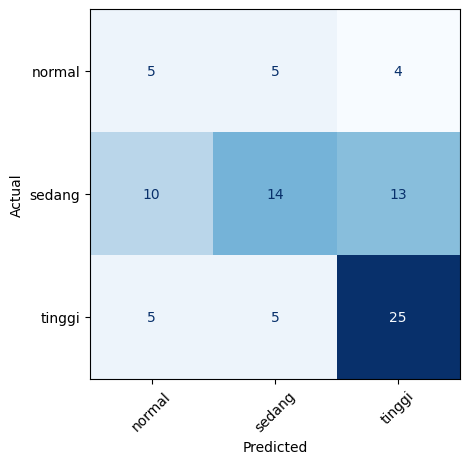

In [37]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

disp.plot(cmap=plt.cm.Blues, values_format="d", xticks_rotation=45, colorbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance

In [38]:
feature_names = ['avg_velocity', 'max_velocity', 'std_velocity', 'total_distance', 'fixation_ratio', 'unique_area_count']
importance = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance)

             feature  importance
2       std_velocity    0.205542
0       avg_velocity    0.197689
3     total_distance    0.188097
1       max_velocity    0.183389
4     fixation_ratio    0.134923
5  unique_area_count    0.090359


# Saving Model

In [39]:
joblib.dump(model, 'model/rfc_3_SMOTE_anxiety_model.pkl')

joblib.dump(scaler, 'model/rfc_3_SMOTE_anxiety_scaler.pkl')

['model/rfc_3_SMOTE_anxiety_scaler.pkl']